## Assignment: $k$ Means Clustering


**Q1.** This is a question about clustering. We want to investigate how adjusting the "noisiness" of the data impacts the quality of the algorithm and the difficulty of picking $k$.

1. Run the code below, which creates four datasets: `df0_125`, `df0_25`, `df0_5`, `df1_0`, and `df2_0`. Each data set is created by increasing the amount of `noise` (standard deviation) around the cluster centers, from `0.125` to `0.25` to `0.5` to `1.0` to `2.0`.

```
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)
```

2. Make scatterplots of the $(X1,X2)$ points by group for each of the datasets. As the `noise` goes up from 0.125 to 2.0, what happens to the visual distinctness of the clusters?
3. Create a scree plot for each of the datasets. Describe how the level of `noise` affects the scree plot (particularly the presence of a clear "elbow") and your ability to definitively select a $k$. (Pay attention to the vertical axis across plots, or put all the scree curves on a single canvas.)
4. Explain the intuition of the elbow, using this numerical simulation as an example.

**Q2.** This question is a case study on clustering.

1. Load the `SIPRI Military Expenditure Database.csv` file in the `./data` folder. This has data about military spending by country. Filter the rows to select only the year 2020, and drop all rows with missing values. I ended up with 148 countries. Is any further cleaning of the variables required?
2. Max-min normalize `Spending (2020 USD)` and `Spending per Capita`. Use a scree plot to determine the optimal number of clusters for the $k$ means clustering algorithm. Make a scatter plot of `Spending (2020 USD)` and `Spending per Capita`, and hue the dots by their cluster membership. Compute a describe table conditional on cluster membership (i.e. `.groupby(cluster).describe()`). What do you see? Where is the United States? Do you notice any patterns in the cluster membership?
3. Repeat part 2 for `Percent of Government Spending` and `Percent of GDP`. How do your results compare to part 2?
4. Use $k$ means clustering with all four numeric variables: `Spending (2020 USD)`, `Spending per Capita`, `Percent of Government Spending`, and `Percent of GDP`. How do your results compare to the previous two parts?
5. Did the $k$-MC algorithm find any useful patterns for you in analyzing the spending?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

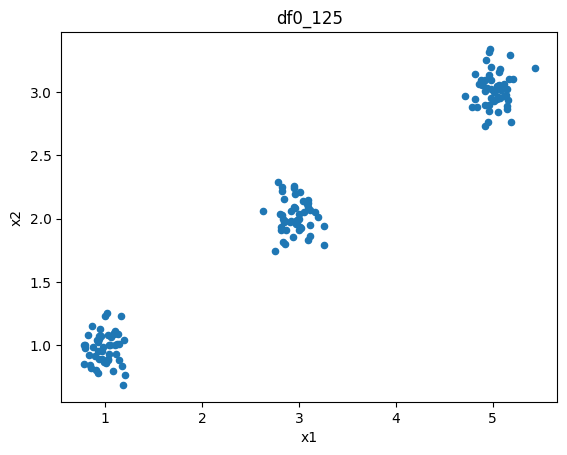

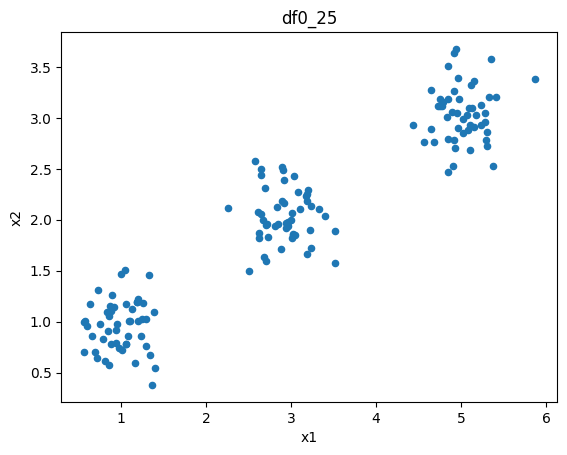

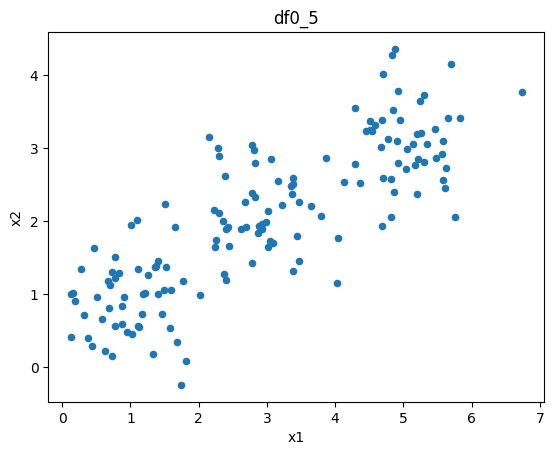

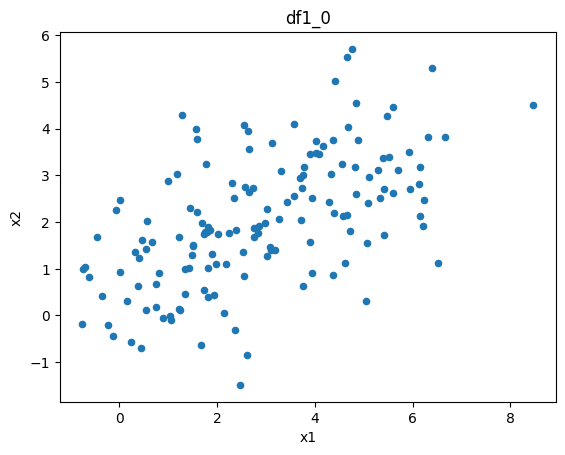

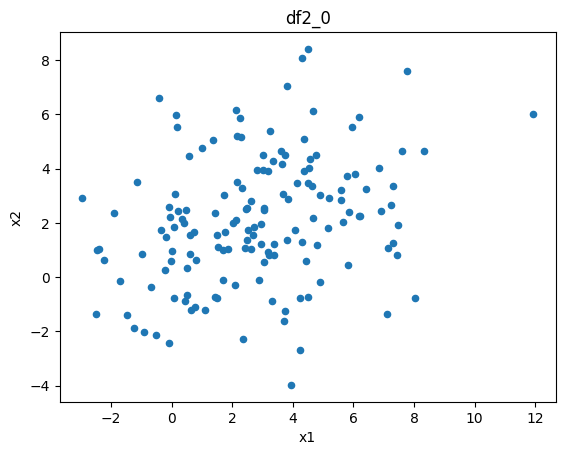


Looking at the scatterplots, the visual distinctness of the clusters diminishes
as the amount of noise in the dataset increases from 0.125 to 2.0. In other words,
the points become more dispersed rather than concentrated, making each individual cluster
harder to distinguish from the other.



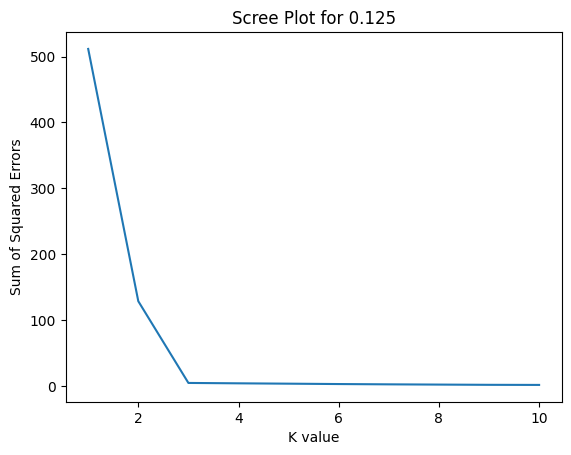

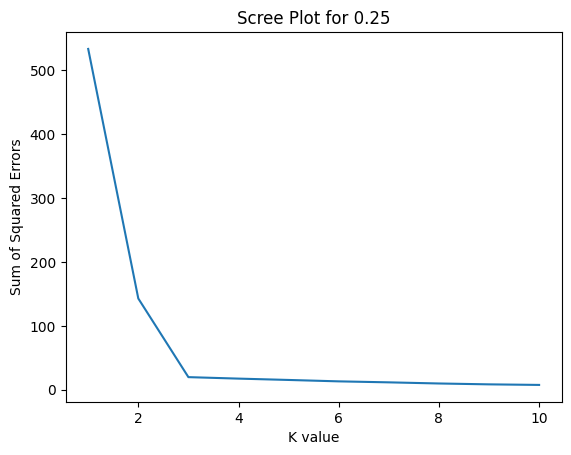

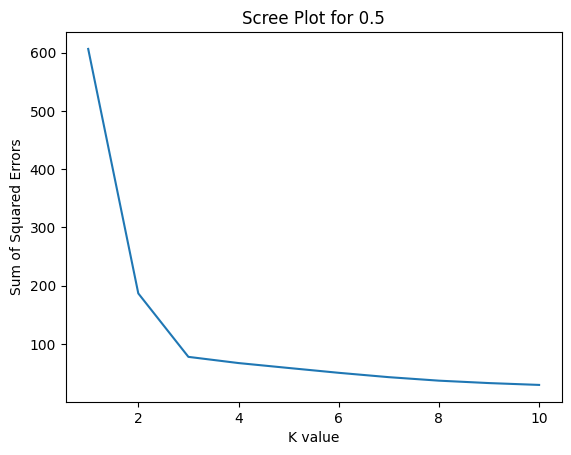

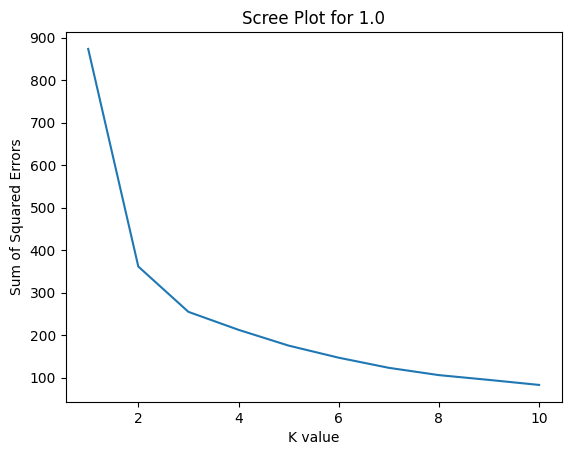

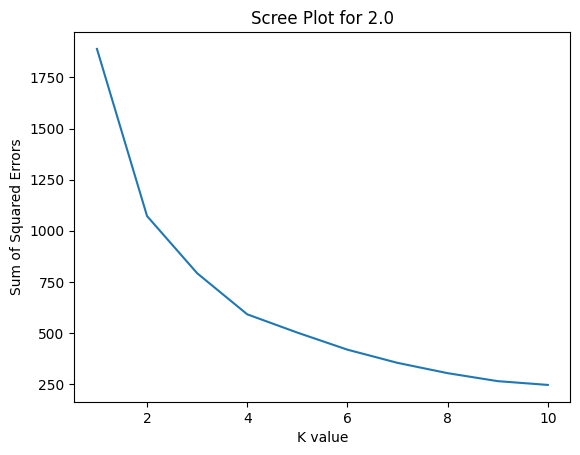


As seen from the scree plots, higher levels of noise make an eblow point less discernable,
with each line plot becoming smoother around the drop-off zone (i.e. the point(s) on the line
at which the SSE drastically drops) from 0.125 to 2.0 noise. For example, at Noise level 0.125,
the elbow is almost certainly located at k = 3. Conversely, the elbow point for Noise Level 2.0
could be any k-value between 3 and 5--this is because there is not as harsh of an inflection point
for decrease in SSE, making it harder to select which of them would be the most correct candidate. 


The elbow point signals a k-value when decreases in error, more specifically SSE, for a given set of k-values
drastically slows down. For example, in the numerical simulations above, elbow points would be the following
k-values: 
  - 0.125: 3 
  - 0.25: 3
  - 0.5: 3
  - 1.0: 3 or 4
  - 2.0: 3,4 or 5
matching these values to the graphs, one can see that these points represent when the SSE--the y-axis--continues to dere

In [20]:
# Your Phase 1 solution to the problem goes here.

# QUESTION 1

# Q1.1
import numpy as np
import pandas as pd

def createData(noise,N=50):
    np.random.seed(100) # Set the seed for replicability
    # Generate (x1,x2,g) triples:
    X1 = np.array([np.random.normal(1,noise,N),np.random.normal(1,noise,N)])
    X2 = np.array([np.random.normal(3,noise,N),np.random.normal(2,noise,N)])
    X3 = np.array([np.random.normal(5,noise,N),np.random.normal(3,noise,N)])
    # Concatenate into one data frame
    gdf1 = pd.DataFrame({'x1':X1[0,:],'x2':X1[1,:],'group':'a'})
    gdf2 = pd.DataFrame({'x1':X2[0,:],'x2':X2[1,:],'group':'b'})
    gdf3 = pd.DataFrame({'x1':X3[0,:],'x2':X3[1,:],'group':'c'})
    df = pd.concat([gdf1,gdf2,gdf3],axis=0)
    return df

df0_125 = createData(0.125)
df0_25 = createData(0.25)
df0_5 = createData(0.5)
df1_0 = createData(1.0)
df2_0 = createData(2.0)

# Q1.2
import matplotlib.pyplot as plt

df0_125.plot.scatter(x='x1', y='x2', title =  "df0_125")
plt.show()
df0_25.plot.scatter(x='x1', y='x2', title =  "df0_25")
plt.show()
df0_5.plot.scatter(x='x1', y='x2', title =  "df0_5")
plt.show()
df1_0.plot.scatter(x='x1', y='x2', title =  "df1_0")
plt.show()
df2_0.plot.scatter(x='x1', y='x2', title =  "df2_0")
plt.show()

print("""
Looking at the scatterplots, the visual distinctness of the clusters diminishes
as the amount of noise in the dataset increases from 0.125 to 2.0. In other words,
the points become more dispersed rather than concentrated, making each individual cluster
harder to distinguish from the other.
""")

# Q1.3
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Drop group column because it is non-numeric and rename dataset to X_i
X_1 = df0_125.drop(columns=["group"])
X_2 = df0_25.drop(columns=["group"])
X_3 = df0_5.drop(columns=["group"])
X_4 = df1_0.drop(columns=["group"])
X_5 = df2_0.drop(columns=["group"])

# 0.125
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_1).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 0.125")
plt.show()

# 0.25
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_2).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 0.25")
plt.show()

# 0.5
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_3).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 0.5")
plt.show()


# 1.0
ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_4).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 1.0")
plt.show()

# 2.0

ks = np.arange(1,11)
SSE = [
    KMeans(n_clusters=k, max_iter=300, n_init=10, random_state=0).fit(X_5).inertia_
    for k in ks
]

plt.figure()
sns.lineplot(x=ks, y=SSE)
plt.xlabel("K value")
plt.ylabel("Sum of Squared Errors")
plt.title("Scree Plot for 2.0")
plt.show()

print("""
As seen from the scree plots, higher levels of noise make an eblow point less discernable,
with each line plot becoming smoother around the drop-off zone (i.e. the point(s) on the line
at which the SSE drastically drops) from 0.125 to 2.0 noise. For example, at Noise level 0.125,
the elbow is almost certainly located at k = 3. Conversely, the elbow point for Noise Level 2.0
could be any k-value between 3 and 5--this is because there is not as harsh of an inflection point
for decrease in SSE, making it harder to select which of them would be the most correct candidate.
""")

# Q1.4
print("""
The elbow point signals a k-value when decreases in error, more specifically SSE, for a given set of k-values
drastically slows down. For example, in the numerical simulations above, elbow points would be the following
k-values:
  - 0.125: 3
  - 0.25: 3
  - 0.5: 3
  - 1.0: 3 or 4
  - 2.0: 3,4 or 5
matching these values to the graphs, one can see that these points represent when the SSE--the y-axis--continues to derease
but much more slowly following them. There are two main concerns that are addressed by utilizing the
elbow point during a k-Means procedure: firstly, it avoids using a k-value that would yield diminishing returns for SSE. Secondly, it helps reduce
the risk of selecting a k-value that overfits the data; in other words, the selected value of k should be accurate but also generalizable,
and higher values of k risk losing the generalizability by matching too closely to the training datapoints rather than simply
capturing the underlying structure. An elbow point maximizes the compactness of the clusters by identifying when SSE steeply declines
whilst avoiding larger k-values that make redundant improvements to error reduction and can risk the model's ability to
accurately cluster different data sets.

""")




In [25]:
# QUESTION 2

!git clone https://github.com/Matthew-Calvario/A04-clustering.git

fatal: destination path 'A04-clustering' already exists and is not an empty directory.


In [27]:
# Q2.1
df = pd.read_csv("/data/SIPRI Military Expenditure Database.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/data/SIPRI Military Expenditure Database.csv'

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]